<a href="https://colab.research.google.com/github/krishna-murari23/UGRP2026/blob/main/Backprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing libraries

In [ ]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)

#Initialising Data

In [ ]:
X = np.array([-1, -0.5, 0.5, 1, 1.5])
Y = X**2
LR = 0.01 #learning rate

#Activation Function - tanh

In [ ]:
def tanh(z):
  return np.tanh(z)

def tanh_grad_from_activation(a):
    return 1.0 - a ** 2

#NN Architecture - Q1

In [ ]:
class SingleHiddenLayerNet:
    def __init__(self, W1, b1, W2, b2):
        self.W1 = W1.astype(float)   # 3x1
        self.b1 = b1.astype(float)   # 3x1
        self.W2 = W2.astype(float)   # 1x3
        self.b2 = b2.astype(float)   # 1x1

    def forward(self, x_scalar):
        x = np.array([[x_scalar]])          # 1x1
        z1 = self.W1 @ x + self.b1          # 3x1
        a1 = tanh(z1)                       # 3x1
        z2 = self.W2 @ a1 + self.b2         # 1x1
        y_hat = z2
        cache = dict(x=x, z1=z1, a1=a1, z2=z2, y_hat=y_hat)
        return y_hat.item(), cache

    def backward(self, cache, y_true):
        x, a1, y_hat = cache["x"], cache["a1"], cache["y_hat"]

        # dL/dy_hat = y_hat - y
        dL_dyhat = y_hat - y_true            # (1x1)
        dL_dz2 = dL_dyhat                    # output layer is linear

        dL_dW2 = dL_dz2 @ a1.T               # 1x3
        dL_db2 = dL_dz2                      # 1x1

        dL_da1 = self.W2.T @ dL_dz2          # 3x1
        dL_dz1 = dL_da1 * tanh_grad_from_activation(a1)  # 3x1

        dL_dW1 = dL_dz1 @ x.T                # 3x1
        dL_db1 = dL_dz1                      # 3x1

        return dict(W1=dL_dW1, b1=dL_db1, W2=dL_dW2, b2=dL_db2)

    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]
        self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]
        self.b2 -= lr * grads["b2"]

    def train_step(self, x_scalar, y_true, lr):
        y_hat, cache = self.forward(x_scalar)
        loss = 0.5 * (y_true - y_hat) ** 2
        grads = self.backward(cache, y_true)
        self.step(grads, lr)
        return y_hat, loss, grads

#NN Architecture - Q2

In [ ]:
class DoubleHiddenLayerNet:
    def __init__(self, W1, b1, W2, b2, W3, b3):
        self.W1 = W1.astype(float)   # 3x1
        self.b1 = b1.astype(float)   # 3x1
        self.W2 = W2.astype(float)   # 3x3
        self.b2 = b2.astype(float)   # 3x1
        self.W3 = W3.astype(float)   # 1x3
        self.b3 = b3.astype(float)   # 1x1

    def forward(self, x_scalar):
        x = np.array([[x_scalar]])
        z1 = self.W1 @ x + self.b1
        a1 = tanh(z1)
        z2 = self.W2 @ a1 + self.b2
        a2 = tanh(z2)
        z3 = self.W3 @ a2 + self.b3
        y_hat = z3
        cache = dict(x=x, z1=z1, a1=a1, z2=z2, a2=a2, z3=z3, y_hat=y_hat)
        return y_hat.item(), cache

    def backward(self, cache, y_true):
        x, a1, a2, y_hat = cache["x"], cache["a1"], cache["a2"], cache["y_hat"]

        dL_dz3 = y_hat - y_true              # linear output layer
        dL_dW3 = dL_dz3 @ a2.T
        dL_db3 = dL_dz3

        dL_da2 = self.W3.T @ dL_dz3
        dL_dz2 = dL_da2 * tanh_grad_from_activation(a2)
        dL_dW2 = dL_dz2 @ a1.T
        dL_db2 = dL_dz2

        dL_da1 = self.W2.T @ dL_dz2
        dL_dz1 = dL_da1 * tanh_grad_from_activation(a1)
        dL_dW1 = dL_dz1 @ x.T
        dL_db1 = dL_dz1

        return dict(W1=dL_dW1, b1=dL_db1, W2=dL_dW2, b2=dL_db2, W3=dL_dW3, b3=dL_db3)

    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]
        self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]
        self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]
        self.b3 -= lr * grads["b3"]

    def train_step(self, x_scalar, y_true, lr):
        y_hat, cache = self.forward(x_scalar)
        loss = 0.5 * (y_true - y_hat) ** 2
        grads = self.backward(cache, y_true)
        self.step(grads, lr)
        return y_hat, loss, grads

#Weights & Biases Initialisation

In [ ]:
W1 = np.array([[0.3], [-0.2], [0.5]])
b1 = np.array([[0.1], [-0.1], [0.05]])
W2 = np.array([[0.4, -0.3, 0.2]])
b2 = np.array([[0.05]])

net_a = SingleHiddenLayerNet(W1, b1, W2, b2)

#Q1

In [ ]:
print("\n" + "=" * 70)
print("TRAINING: single hidden layer network on all input")
print("=" * 70)

rng = np.random.default_rng(0)
net_a2 = SingleHiddenLayerNet(
    rng.normal(0, 0.5, (3, 1)), np.zeros((3, 1)),
    rng.normal(0, 0.5, (1, 3)), np.zeros((1, 1)),
)

epochs = 3000
for epoch in range(epochs):
    epoch_loss = 0.0
    for x_i, y_i in zip(X, Y):
        y_hat, loss, grads = net_a2.train_step(x_i, y_i, LR)
        epoch_loss += loss
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:4d}  mean loss = {epoch_loss / len(X):.6f}")

print("\nFinal predictions (Q1 ):")
for x_i, y_i in zip(X, Y):
    y_hat, _ = net_a2.forward(x_i)
    print(f"  x={x_i:5.2f}  y_true={y_i:.4f}  y_hat={y_hat:.4f}")


TRAINING: single hidden layer network on all input
epoch    0  mean loss = 0.655854
epoch  500  mean loss = 0.159026
epoch 1000  mean loss = 0.044743
epoch 1500  mean loss = 0.012403
epoch 2000  mean loss = 0.010017
epoch 2500  mean loss = 0.008358
epoch 2999  mean loss = 0.006832

Final predictions (Q1 ):
  x=-1.00  y_true=1.0000  y_hat=0.8685
  x=-0.50  y_true=0.2500  y_hat=0.4344
  x= 0.50  y_true=0.2500  y_hat=0.1460
  x= 1.00  y_true=1.0000  y_hat=1.0531
  x= 1.50  y_true=2.2500  y_hat=2.2271


#Q2

In [ ]:
print("\n" + "=" * 70)
print("TRAINING: double hidden layer network on input")
print("=" * 70)

net_b = DoubleHiddenLayerNet(
    rng.normal(0, 0.5, (3, 1)), np.zeros((3, 1)),
    rng.normal(0, 0.5, (3, 3)), np.zeros((3, 1)),
    rng.normal(0, 0.5, (1, 3)), np.zeros((1, 1)),
)

for epoch in range(epochs):
    epoch_loss = 0.0
    for x_i, y_i in zip(X, Y):
        y_hat, loss, grads = net_b.train_step(x_i, y_i, LR)
        epoch_loss += loss
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:4d}  mean loss = {epoch_loss / len(X):.6f}")

print("\nFinal predictions (Q1):")
for x_i, y_i in zip(X, Y):
    y_hat, _ = net_b.forward(x_i)
    print(f"  x={x_i:5.2f}  y_true={y_i:.4f}  y_hat={y_hat:.4f}")


TRAINING: double hidden layer network on input
epoch    0  mean loss = 0.913515
epoch  500  mean loss = 0.074595
epoch 1000  mean loss = 0.040946
epoch 1500  mean loss = 0.025488
epoch 2000  mean loss = 0.020367
epoch 2500  mean loss = 0.012957
epoch 2999  mean loss = 0.006294

Final predictions (Q1):
  x=-1.00  y_true=1.0000  y_hat=0.8652
  x=-0.50  y_true=0.2500  y_hat=0.4250
  x= 0.50  y_true=0.2500  y_hat=0.1617
  x= 1.00  y_true=1.0000  y_hat=1.0332
  x= 1.50  y_true=2.2500  y_hat=2.2311


# Plots

Re-training Single Hidden Layer Network to collect loss data...
Re-training Double Hidden Layer Network to collect loss data...


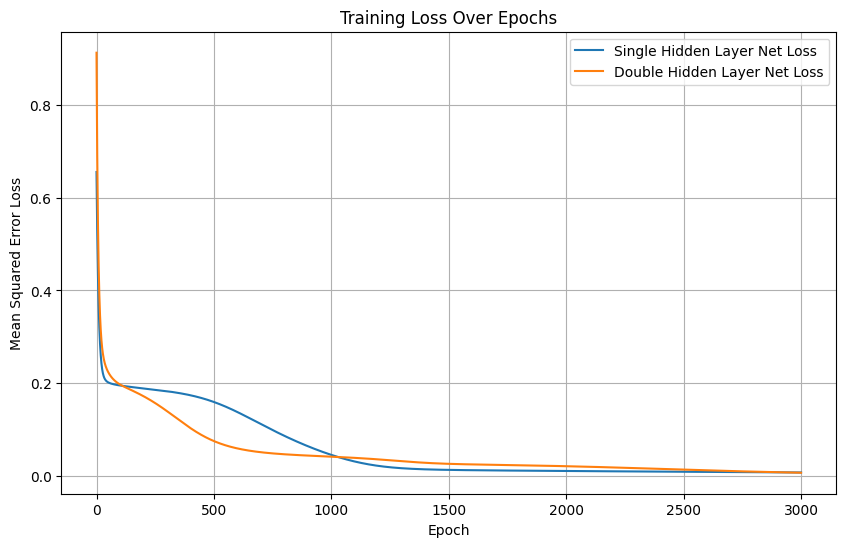

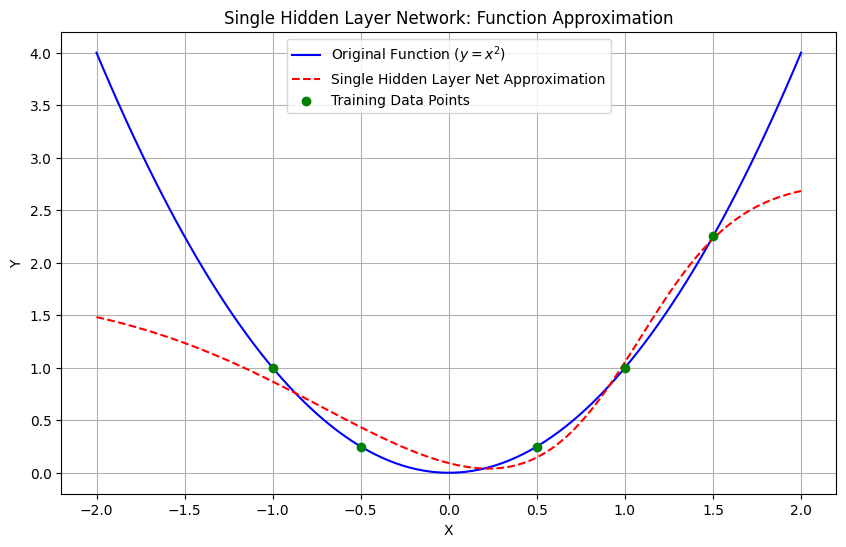

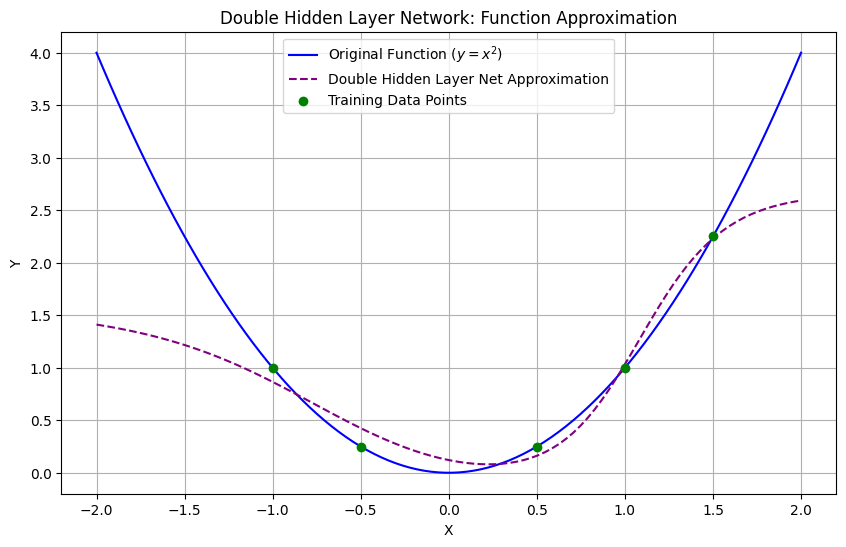

In [ ]:
import matplotlib.pyplot as plt

# Re-define parameters for reproducibility and to ensure they are available
LR = 0.01 #learning rate
epochs = 3000
rng = np.random.default_rng(0)

print("Re-training Single Hidden Layer Network to collect loss data...")
# Re-initialize and re-train net_a2 to collect losses
net_a2_plot = SingleHiddenLayerNet(
    rng.normal(0, 0.5, (3, 1)), np.zeros((3, 1)),
    rng.normal(0, 0.5, (1, 3)), np.zeros((1, 1)),
)
losses_a2 = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for x_i, y_i in zip(X, Y):
        y_hat, loss, grads = net_a2_plot.train_step(x_i, y_i, LR)
        epoch_loss += loss
    losses_a2.append(epoch_loss / len(X))

print("Re-training Double Hidden Layer Network to collect loss data...")
# Re-initialize and re-train net_b to collect losses
net_b_plot = DoubleHiddenLayerNet(
    rng.normal(0, 0.5, (3, 1)), np.zeros((3, 1)),
    rng.normal(0, 0.5, (3, 3)), np.zeros((3, 1)),
    rng.normal(0, 0.5, (1, 3)), np.zeros((1, 1)),
)
losses_b = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for x_i, y_i in zip(X, Y):
        y_hat, loss, grads = net_b_plot.train_step(x_i, y_i, LR)
        epoch_loss += loss
    losses_b.append(epoch_loss / len(X))

# Plotting Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(losses_a2, label='Single Hidden Layer Net Loss')
plt.plot(losses_b, label='Double Hidden Layer Net Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True)
plt.show()

# Generate a denser range for plotting approximations
x_plot = np.linspace(-2, 2, 100).reshape(-1, 1) # Reshape for compatibility
y_true_plot = x_plot**2

# Get predictions from both networks for plotting
y_hat_a2_plot = np.array([net_a2_plot.forward(x_val.item())[0] for x_val in x_plot])
y_hat_b_plot = np.array([net_b_plot.forward(x_val.item())[0] for x_val in x_plot])

# Plotting Approximation for Single Hidden Layer Network
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true_plot, label='Original Function ($y=x^2$)', color='blue')
plt.plot(x_plot, y_hat_a2_plot, label='Single Hidden Layer Net Approximation', color='red', linestyle='--')
plt.scatter(X, Y, label='Training Data Points', color='green', zorder=5)
plt.title('Single Hidden Layer Network: Function Approximation')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Approximation for Double Hidden Layer Network
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true_plot, label='Original Function ($y=x^2$)', color='blue')
plt.plot(x_plot, y_hat_b_plot, label='Double Hidden Layer Net Approximation', color='purple', linestyle='--')
plt.scatter(X, Y, label='Training Data Points', color='green', zorder=5)
plt.title('Double Hidden Layer Network: Function Approximation')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# Extract activations from the second hidden layer (a2) for training data
X_lr_train = []
for x_i in X:
    _, cache = net_b_plot.forward(x_i)
    X_lr_train.append(cache['a2'].flatten()) # Flatten a2 to use as features
X_lr_train = np.array(X_lr_train)

# Y is already suitable as the target for linear regression
Y_lr_train = Y

# Initialize and train the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_lr_train, Y_lr_train)

print("Linear Regression Coefficients:", linear_model.coef_)
print("Linear Regression Intercept:", linear_model.intercept_)

Linear Regression Coefficients: [-0.525802  1.327356 -0.878266]
Linear Regression Intercept: 2.011112356906154


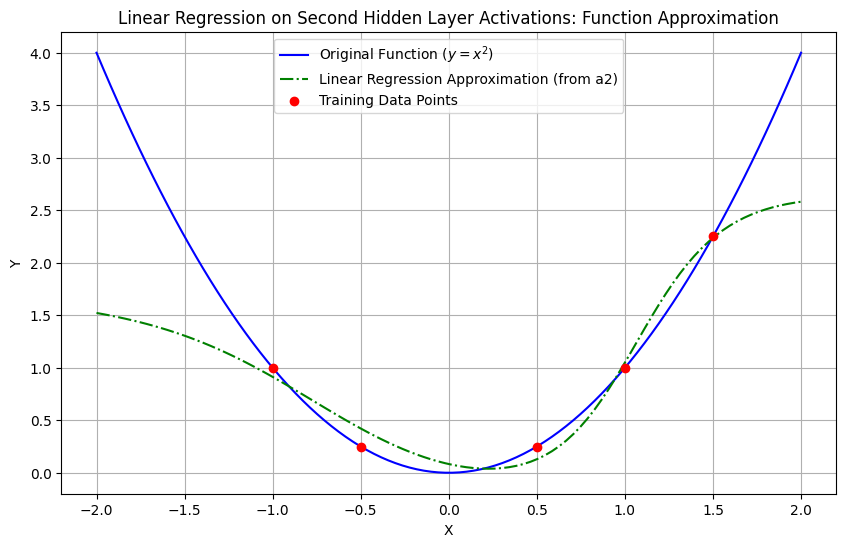

In [ ]:
# Generate predictions for the plot using the linear regression model
X_lr_plot = []
for x_val in x_plot:
    _, cache = net_b_plot.forward(x_val.item())
    X_lr_plot.append(cache['a2'].flatten())
X_lr_plot = np.array(X_lr_plot)

y_hat_lr_plot = linear_model.predict(X_lr_plot)

# Plotting Linear Regression Approximation
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true_plot, label='Original Function ($y=x^2$)', color='blue')
plt.plot(x_plot, y_hat_lr_plot, label='Linear Regression Approximation (from a2)', color='green', linestyle='-.')
plt.scatter(X, Y, label='Training Data Points', color='red', zorder=5)
plt.title('Linear Regression on Second Hidden Layer Activations: Function Approximation')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

y_pred_train_lr = linear_model.predict(X_lr_train)
mse_lr = mean_squared_error(Y_lr_train, y_pred_train_lr)
print(f"Final Mean Squared Error for the Linear Regression Model: {mse_lr:.6f}")

Final Mean Squared Error for the Linear Regression Model: 0.010873
